In [1]:
#Carga y configuración inicial
import pandas as pd
import numpy as np

# Crear dataset de ejemplo de e-commerce
np.random.seed(42)
n_orders = 1000

df = pd.DataFrame({
    'order_id': range(1, n_orders + 1),
    'customer_id': np.random.randint(1, 201, n_orders),
    'product_id': np.random.randint(1, 51, n_orders),
    'quantity': np.random.randint(1, 5, n_orders),
    'unit_price': np.round(np.random.uniform(10, 500, n_orders), 2),
    'order_date': pd.date_range('2023-01-01', periods=n_orders, freq='H')[:n_orders],
    'payment_method': np.random.choice(['Credit Card', 'Debit Card', 'PayPal', 'Cash'], n_orders),
    'customer_age': np.random.normal(35, 10, n_orders).clip(18, 80).astype(int),
    'shipping_region': np.random.choice(['North', 'South', 'East', 'West'], n_orders)
})

# Introducir algunos valores faltantes
mask = np.random.random(n_orders) < 0.05
df.loc[mask, 'customer_age'] = np.nan

print("Dataset cargado exitosamente")

Dataset cargado exitosamente


In [2]:
df

,order_id,customer_id,product_id,quantity,unit_price,order_date,payment_method,customer_age,shipping_region
0,1,103,40,2,371.34,2023-01-01 00:00:00,Debit Card,32.0,West
1,2,180,49,2,260.99,2023-01-01 01:00:00,Debit Card,44.0,West
2,3,93,44,3,343.31,2023-01-01 02:00:00,Credit Card,39.0,West
3,4,15,19,2,30.42,2023-01-01 03:00:00,Cash,35.0,North
4,5,107,42,2,51.55,2023-01-01 04:00:00,PayPal,36.0,North
...,...,...,...,...,...,...,...,...,...
995,996,111,33,3,480.71,2023-02-11 11:00:00,Cash,53.0,South
996,997,111,13,4,106.49,2023-02-11 12:00:00,Cash,27.0,South
997,998,34,26,1,476.20,2023-02-11 13:00:00,Debit Card,37.0,South
998,999,111,22,3,497.46,2023-02-11 14:00:00,Cash,20.0,West


In [3]:
#Inspección inicial sistemática
# Dimensiones y estructura
print(f"Dataset shape: {df.shape}")
print(f"\nColumnas: {list(df.columns)}")
print(f"\nTipos de datos:\n{df.dtypes}")

# Primeras y últimas filas
print("\nPrimeras 5 filas:")
print(df.head())

print("\nÚltimas 5 filas:")
print(df.tail())

Dataset shape: (1000, 9)

Columnas: ['order_id', 'customer_id', 'product_id', 'quantity', 'unit_price', 'order_date', 'payment_method', 'customer_age', 'shipping_region']

Tipos de datos:
order_id                    int64
customer_id                 int32
product_id                  int32
quantity                    int32
unit_price                float64
order_date         datetime64[ns]
payment_method             object
customer_age              float64
shipping_region            object
dtype: object

Primeras 5 filas:
   order_id  customer_id  product_id  quantity  unit_price  \
0         1          103          40         2      371.34   
1         2          180          49         2      260.99   
2         3           93          44         3      343.31   
3         4           15          19         2       30.42   
4         5          107          42         2       51.55   

           order_date payment_method  customer_age shipping_region  
0 2023-01-01 00:00:00     Debit

In [5]:
# Análisis de calidad de datos
# Valores faltantes
print("Valores faltantes por columna:")
print(df.isnull().sum())

print(f"\nPorcentaje de completitud: {(1 - df.isnull().sum() / len(df)) * 100}")

# Valores únicos por columna
print("\nValores únicos por columna:")
for col in df.select_dtypes(include=['object']).columns:
    print(f"{col}: {df[col].nunique()} valores únicos")

# Estadísticos básicos para numéricas
print("\nEstadísticos básicos de variables numéricas:")
print(df.select_dtypes(include=[np.number]).describe())

Valores faltantes por columna:
order_id            0
customer_id         0
product_id          0
quantity            0
unit_price          0
order_date          0
payment_method      0
customer_age       46
shipping_region     0
dtype: int64

Porcentaje de completitud: order_id           100.0
customer_id        100.0
product_id         100.0
quantity           100.0
unit_price         100.0
order_date         100.0
payment_method     100.0
customer_age        95.4
shipping_region    100.0
dtype: float64

Valores únicos por columna:
payment_method: 4 valores únicos
shipping_region: 4 valores únicos

Estadísticos básicos de variables numéricas:
          order_id  customer_id   product_id     quantity   unit_price  \
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000   
mean    500.500000   101.697000    25.680000     2.469000   253.828640   
std     288.819436    57.629249    14.180645     1.121739   141.648562   
min       1.000000     1.000000     1.000000     1.0

In [6]:
# Preguntas exploratorias iniciales
# Distribución por región
print("Distribución de pedidos por región:")
print(df['shipping_region'].value_counts())

# Método de pago más popular
print(f"\nMétodo de pago más usado: {df['payment_method'].value_counts().index[0]}")

# Rango de fechas
print(f"\nPeríodo de datos: {df['order_date'].min()} a {df['order_date'].max()}")

# Edad promedio de clientes
edad_promedio = df['customer_age'].mean()
print(f"\nEdad promedio de clientes: {edad_promedio:.1f} años")

Distribución de pedidos por región:
shipping_region
South    267
North    250
East     246
West     237
Name: count, dtype: int64

Método de pago más usado: Credit Card

Período de datos: 2023-01-01 00:00:00 a 2023-02-11 15:00:00

Edad promedio de clientes: 34.7 años


C:\Users\mfram\anaconda31\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


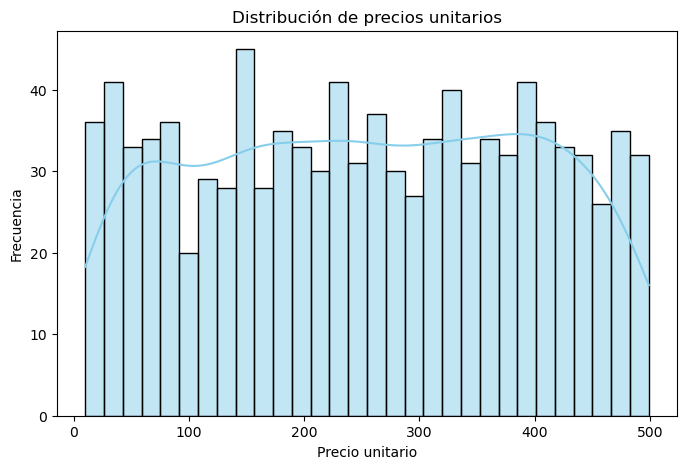

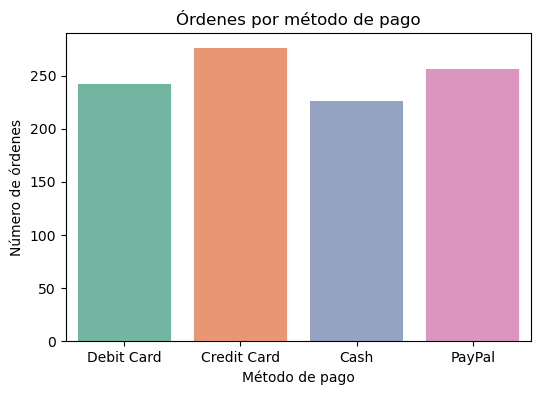

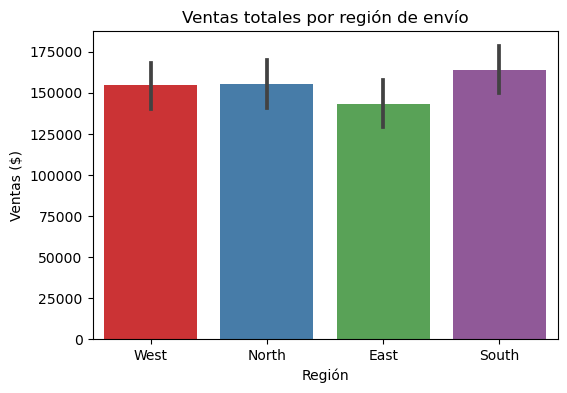

C:\Users\mfram\anaconda31\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\mfram\anaconda31\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


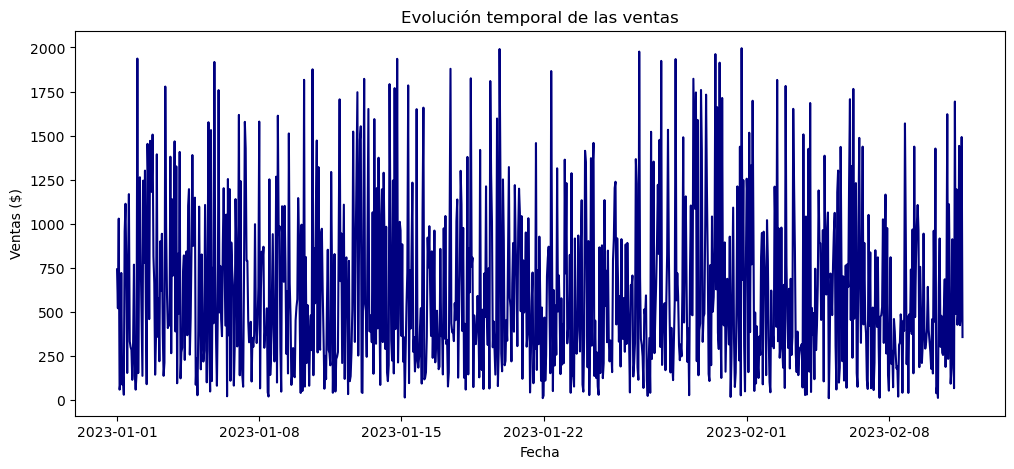

C:\Users\mfram\anaconda31\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


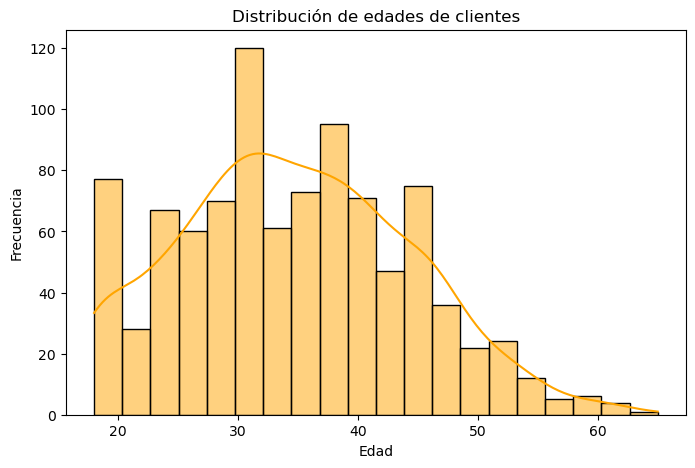

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Asegurar columna de ventas
df['sales'] = df['quantity'] * df['unit_price']

# Distribución de precios unitarios
plt.figure(figsize=(8,5))
sns.histplot(df['unit_price'], bins=30, kde=True, color='skyblue')
plt.title("Distribución de precios unitarios")
plt.xlabel("Precio unitario")
plt.ylabel("Frecuencia")
plt.show()

# Órdenes por método de pago
plt.figure(figsize=(6,4))
sns.countplot(x='payment_method', data=df, palette='Set2')
plt.title("Órdenes por método de pago")
plt.xlabel("Método de pago")
plt.ylabel("Número de órdenes")
plt.show()

# Ventas totales por región de envío
plt.figure(figsize=(6,4))
sns.barplot(x='shipping_region', y='sales', data=df, estimator=np.sum, palette='Set1')
plt.title("Ventas totales por región de envío")
plt.xlabel("Región")
plt.ylabel("Ventas ($)")
plt.show()

# Evolución temporal de las ventas
sales_time = df.groupby('order_date')['sales'].sum().reset_index()
plt.figure(figsize=(12,5))
sns.lineplot(x='order_date', y='sales', data=sales_time, color='navy')
plt.title("Evolución temporal de las ventas")
plt.xlabel("Fecha")
plt.ylabel("Ventas ($)")
plt.show()

# Distribución de edades de clientes
plt.figure(figsize=(8,5))
sns.histplot(df['customer_age'].dropna(), bins=20, kde=True, color='orange')
plt.title("Distribución de edades de clientes")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()